In [ ]:
# eda05: chain registration transforms, register all exposures to reference (shortest), weighted merge
import math
import numpy as np
import torch
import pickle
import tqdm
from pathlib import Path
from PIL import Image
import enum
from dataclasses import dataclass

class MoonInfoOrigin(enum.Enum):
    DIRECT = 0
    INTERPOLATED = 1

@dataclass
class ImageInfo:
    path: Path
    width: int
    height: int
    avg_brightness: float
    timestamp: float
    exposure_time: float
    moon: tuple[float, float, float] = None
    moon_info_origin: MoonInfoOrigin = None
    moon_pos_std_px: float = None

PKL_DIR = "/home/slavik/tmp"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load eda02 (exposure_groups, opt_results) and eda03 (cross_reg, gamma_by_pair)
with open(f"{PKL_DIR}/eda02.pkl", "rb") as fd:
    exposure_groups = pickle.load(fd)
    reg = pickle.load(fd)
    opt_results = pickle.load(fd)
with open(f"{PKL_DIR}/eda03.pkl", "rb") as fd:
    cross_reg = pickle.load(fd)
    gamma_by_pair = pickle.load(fd)

exposure_times_sorted = sorted(exposure_groups.keys())
# Reference = first (shortest) exposure
t_ref = exposure_times_sorted[0]

def moon_median(group):
    centers_i = [ii.moon[0] for ii in group]
    centers_j = [ii.moon[1] for ii in group]
    radii = [ii.moon[2] for ii in group]
    return (float(np.median(centers_i)), float(np.median(centers_j)), float(np.median(radii)))

moon_ref = moon_median(exposure_groups[t_ref])
print(f"Reference exposure t_ref={t_ref}, moon_ref (i,j,r)={moon_ref}")
print(f"cross_reg pairs: {len(cross_reg)}, gamma_by_pair: {len(gamma_by_pair)}")

In [ ]:
# Recompute per-exposure averaged images (same logic as eda03; not saved there)
def load_grayscale(ii, device):
    with Image.open(ii.path) as img:
        arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    return torch.from_numpy(arr).to(device=device, dtype=torch.float32)

def apply_transform_single(img, shift_i, shift_j, angle_deg, device):
    H, W = img.shape
    ci, cj = H / 2.0, W / 2.0
    angle_rad = math.radians(-angle_deg)
    cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    di = ii - ci - shift_i
    dj = jj - cj - shift_j
    i_src = di * cos_a + dj * sin_a + ci
    j_src = -di * sin_a + dj * cos_a + cj
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

def compute_weighted_average(group, abs_xy, abs_angle_t, device, epsilon=1e-6):
    n = len(group)
    sum_img = None
    sum_mask = None
    for j in range(n):
        img_j = load_grayscale(group[j], device)
        mj_i, mj_j, r_j = group[j].moon[0], group[j].moon[1], group[j].moon[2]
        H, W = img_j.shape
        ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
        jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
        dist = torch.sqrt((ii - mj_i) ** 2 + (jj - mj_j) ** 2)
        # Fill moon with black (radius = moon radius + 2) in this image before warping
        img_j = img_j.clone()
        mask_j = (dist > r_j + 2.0).to(torch.float32)
        x_j = float(abs_xy[j, 0])
        y_j = float(abs_xy[j, 1])
        theta_j_deg = -math.degrees(float(abs_angle_t[j]))
        w_img = apply_transform_single(img_j, x_j, y_j, theta_j_deg, device)
        w_mask = apply_transform_single(mask_j, x_j, y_j, theta_j_deg, device)
        if sum_img is None:
            sum_img = w_img * w_mask
            sum_mask = w_mask.clone()
        else:
            sum_img = sum_img + w_img * w_mask
            sum_mask = sum_mask + w_mask
    avg_img = sum_img / (sum_mask + epsilon)
    avg_mask = sum_mask / n
    return avg_img, avg_mask

avg_images = {}
avg_masks = {}
for exp in tqdm.tqdm(exposure_times_sorted, desc="Averaged images"):
    group = exposure_groups[exp]
    if exp not in opt_results or len(group) < 2:
        continue
    abs_xy = torch.from_numpy(opt_results[exp]["abs_xy"]).to(device)
    abs_angle_t = torch.from_numpy(opt_results[exp]["abs_angle_t"]).to(device)
    avg_images[exp], avg_masks[exp] = compute_weighted_average(group, abs_xy, abs_angle_t, device)

print(f"Built {len(avg_images)} averaged images.")
H_ref, W_ref = next(iter(avg_images.values())).shape
print(f"Reference shape H={H_ref}, W={W_ref}")

In [ ]:
# Build ref->k sampling grid by chaining pairwise transforms; scale factor to ref intensity
def ref_to_source_grid(H, W, chain_tuples, device):
    """chain_tuples: list of (shift_i, shift_j, rotation_deg) for (t0,t1), (t1,t2), ..."""
    ci, cj = H / 2.0, W / 2.0
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    i_cur = ii.clone()
    j_cur = jj.clone()
    for (shift_i, shift_j, rotation_deg) in chain_tuples:
        angle_rad = math.radians(-rotation_deg)
        cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
        di = i_cur - ci - shift_i
        dj = j_cur - cj - shift_j
        i_cur = di * cos_a + dj * sin_a + ci
        j_cur = -di * sin_a + dj * cos_a + cj
    return i_cur, j_cur

def grid_to_normalized_grid(i_src, j_src, H, W):
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    return torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)

def warp_to_ref(img, chain_tuples, H_ref, W_ref, device):
    """Warp img (same or larger concept size) to reference grid using chain ref->source."""
    i_src, j_src = ref_to_source_grid(H_ref, W_ref, chain_tuples, device)
    grid = grid_to_normalized_grid(i_src, j_src, img.shape[0], img.shape[1])
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

# Scale factor to bring exposure t_k value to t_ref scale: value_ref = value_k * scale_k
# scale_k = (t_ref/t_1)^(1/g1) * (t_1/t_2)^(1/g2) * ... * (t_{k-1}/t_k)^(1/g_k)
def scale_to_ref(exposure_times_sorted, gamma_by_pair, k):
    if k == 0:
        return 1.0
    scale = 1.0
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in gamma_by_pair:
            return None
        g = gamma_by_pair[(t0, t1)]
        scale *= (t0 / t1) ** (1.0 / g)
    return scale

# Exposures that have both avg_image and a chain from ref (consecutive pairs present)
exposures_with_chain = [t_ref]
chain_tuples_by_exp = {t_ref: []}  # ref -> ref is identity
for k in range(1, len(exposure_times_sorted)):
    t_k = exposure_times_sorted[k]
    if t_k not in avg_images:
        continue
    chain = []
    valid = True
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in cross_reg:
            valid = False
            break
        chain.append(cross_reg[(t0, t1)])
    if not valid:
        continue
    chain_tuples_by_exp[t_k] = chain
    exposures_with_chain.append(t_k)

print(f"Exposures in chain: {len(exposures_with_chain)}")

In [ ]:
# Weight from original (untransformed) value: exp(-((y-0.5)/0.1)^2), y clipped to [0,1]
WEIGHT_SIGMA = 0.2

def weight_from_value(y):
    y = np.clip(y, 0.0, 1.0).astype(np.float64)
    return np.exp(-((y - 0.5) / WEIGHT_SIGMA) ** 2)

# Accumulate weighted average in float64; track valid per exposure for crop
sum_val = np.zeros((H_ref, W_ref), dtype=np.float64)
sum_weight = np.zeros((H_ref, W_ref), dtype=np.float64)
valid_all = None  # intersection of warped valid masks (float, 1 where all exposures cover)
mask_0 = avg_masks[min(avg_masks.keys())] > 0.99
for t_k in tqdm.tqdm(exposures_with_chain, desc="Warp and merge"):
    img_k = avg_images[t_k]
    mask_k = avg_masks[t_k]
    chain = chain_tuples_by_exp[t_k]
    k_idx = exposure_times_sorted.index(t_k)
    scale_k = scale_to_ref(exposure_times_sorted, gamma_by_pair, k_idx)
    if scale_k is None:
        continue

    # Original (unscaled) and scaled value, clipped to [0,1]
    orig = img_k.cpu().numpy().astype(np.float64)
    orig_clip = np.clip(orig, 0.0, 1.0)
    value_scaled = np.clip(orig * scale_k, 0.0, 1.0)
    weight_img = weight_from_value(orig_clip)
    if k_idx > 0:
        weight_img *= (mask_k > 0.99).detach().cpu().numpy()

    # Warp to reference grid
    val_t = torch.from_numpy(value_scaled.astype(np.float32)).to(device)
    w_t = torch.from_numpy(weight_img.astype(np.float32)).to(device)
    valid_t = torch.ones_like(img_k, device=device, dtype=torch.float32)
    warped_val = (warp_to_ref(val_t, chain, H_ref, W_ref, device) * mask_0).cpu().numpy().astype(np.float64)
    warped_w = warp_to_ref(w_t, chain, H_ref, W_ref, device).cpu().numpy().astype(np.float64)
    warped_valid = warp_to_ref(valid_t, chain, H_ref, W_ref, device).cpu().numpy()

    # Only count where this exposure actually covers (avoid border pull-down)
    use = warped_valid >= 0.5
    sum_val += np.where(use, warped_val * warped_w, 0.0)
    sum_weight += np.where(use, warped_w, 0.0)

    if valid_all is None:
        valid_all = warped_valid.copy()
    else:
        valid_all = np.minimum(valid_all, warped_valid)

# Pixels with at least some weight (always true if clipped; defensive)
denom = np.maximum(sum_weight, 1e-20)
composite = (sum_val / denom).astype(np.float64)
print(f"Composite shape {composite.shape}, dtype {composite.dtype}")

In [ ]:
# Crop to rectangle where all exposures have valid coverage (valid_all >= 0.5)
VALID_THRESH = 0.9999
all_valid_mask = valid_all >= VALID_THRESH
rows = np.any(all_valid_mask, axis=1)
cols = np.any(all_valid_mask, axis=0)
r_lo, r_hi = np.where(rows)[0][[0, -1]]
c_lo, c_hi = np.where(cols)[0][[0, -1]]
r_lo += 16
r_hi -= 16
c_lo += 16
c_hi -= 16
composite_crop = composite[r_lo : r_hi + 1, c_lo : c_hi + 1].copy()
# Moon center in ref image; crop offset for moon fill
mi, mj, moon_r = moon_ref
mi_crop = mi - r_lo
mj_crop = mj - c_lo
H_crop, W_crop = composite_crop.shape
print(f"Crop bounds rows [{r_lo},{r_hi}], cols [{c_lo},{c_hi}]; shape {composite_crop.shape}")

# Moon mask (for stats/display; moon already black from compute_weighted_average)
ii = np.arange(H_crop, dtype=np.float64).reshape(-1, 1)
jj = np.arange(W_crop, dtype=np.float64).reshape(1, -1)
dist_sq = (ii - mi_crop) ** 2 + (jj - mj_crop) ** 2
moon_mask = dist_sq <= (moon_r ** 2)

In [ ]:
# Save composite (float64) and a preview image
out_dir = Path(PKL_DIR)
np.save(out_dir / "eda05_composite.npy", composite_crop)
# Preview: normalize to [0,1] for display (or use percentile clip)
v_min = np.percentile(composite_crop[~moon_mask] if np.any(~moon_mask) else composite_crop, 1)
v_max = np.percentile(composite_crop[~moon_mask] if np.any(~moon_mask) else composite_crop, 99)
preview = np.clip((composite_crop - v_min) / (v_max - v_min + 1e-9), 0, 1)
Image.fromarray((preview * 255).clip(0, 255).astype(np.uint8)).save(out_dir / "eda05_composite_preview.png")
print(f"Saved {out_dir / 'eda05_composite.npy'} (float64), {out_dir / 'eda05_composite_preview.png'}")

In [ ]:
if False:
    lv_max = composite_crop.max()
    for i in range(10):
        preview = np.clip(composite_crop / lv_max, 0, 1)
        Image.fromarray((preview * 255).clip(0, 255).astype(np.uint8)).save(out_dir / f"eda05_composite_preview_{i}.png")
        lv_max /= 2
    raise


In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(composite_crop, cmap="gray", vmin=0, vmax=np.percentile(composite_crop[composite_crop > 0], 99) if np.any(composite_crop > 0) else 1)
ax.set_title("eda05 composite (ref frame, weighted merge, moon black)")
plt.tight_layout()
plt.show()

In [ ]:
# find_moon + refine_moon from eda00.py: exact moon (center, radius) from edge gradient, given initial (i0, j0)
import math
import random
import numpy as np
import torch
from scipy.cluster.hierarchy import linkage, fcluster

N_SECTORS = 360
N_TRIPLETS = 1024
N_CLUSTER = 256
REFINE_ITERATIONS = 3
MIN_TRIPLET_DEGREES = 30

def _indices_within_degrees(center: int, deg: int) -> set:
    return {(center + d) % N_SECTORS for d in range(-(deg - 1), deg)}

def sample_triplet_indices(n_pts: int, min_degrees: int = MIN_TRIPLET_DEGREES):
    available = set(range(n_pts))
    a = random.sample(list(available), 1)[0]
    available -= _indices_within_degrees(a, min_degrees) & available
    assert len(available) >= 2
    b = random.sample(list(available), 1)[0]
    available -= _indices_within_degrees(b, min_degrees) & available
    assert len(available) >= 1
    c = random.sample(list(available), 1)[0]
    return (a, b, c)

def refine_moon(img: torch.Tensor, center_i: float, center_j: float):
    assert img.ndim == 3 and img.shape[2] == 3
    H, W = img.shape[0], img.shape[1]
    dev = img.device
    img_size = float(max(H, W))
    gray = img.mean(dim=2)
    sobel_x = torch.tensor(
        [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32, device=dev
    ).view(1, 1, 3, 3)
    sobel_y = torch.tensor(
        [[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32, device=dev
    ).view(1, 1, 3, 3)
    g = gray.unsqueeze(0).unsqueeze(0)
    grad_x = torch.nn.functional.conv2d(g, sobel_x, padding=1).squeeze()
    grad_y = torch.nn.functional.conv2d(g, sobel_y, padding=1).squeeze()
    dy = torch.arange(H, device=dev, dtype=torch.float32).view(-1, 1) - center_i
    dx = torch.arange(W, device=dev, dtype=torch.float32).view(1, -1) - center_j
    norm = torch.sqrt(dx * dx + dy * dy).clamp(min=1e-6)
    u_x, u_y = dx / norm, dy / norm
    angle = torch.atan2(dy, dx)
    sector_id = (
        torch.floor((angle + math.pi) / (2 * math.pi) * N_SECTORS).long() % N_SECTORS
    )
    dot_product = grad_x * u_x + grad_y * u_y
    dot_product_flat = dot_product.reshape(-1)
    sector_flat = sector_id.reshape(-1)
    W_t = W
    points_list = []
    for s in range(N_SECTORS):
        mask = sector_flat == s
        if mask.any():
            masked = torch.where(
                mask, dot_product_flat, torch.tensor(-1e9, device=dev, dtype=torch.float32)
            )
            idx = masked.argmax().item()
            i, j = idx // W_t, idx % W_t
            points_list.append((i, j))
    n_pts = len(points_list)
    if n_pts < 3:
        return (center_i, center_j, 0.0)

    def circumcenter(i1, j1, i2, j2, i3, j3):
        x1, y1 = float(j1), float(i1)
        x2, y2 = float(j2), float(i2)
        x3, y3 = float(j3), float(i3)
        D = 2.0 * (x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2))
        if abs(D) < 1e-10:
            return None
        ox = (
            (x1 * x1 + y1 * y1) * (y2 - y3)
            + (x2 * x2 + y2 * y2) * (y3 - y1)
            + (x3 * x3 + y3 * y3) * (y1 - y2)
        ) / D
        oy = (
            (x1 * x1 + y1 * y1) * (x3 - x2)
            + (x2 * x2 + y2 * y2) * (x1 - x3)
            + (x3 * x3 + y3 * y3) * (x2 - x1)
        ) / D
        oi, oj = oy, ox
        d1 = math.hypot(i1 - oi, j1 - oj)
        d2 = math.hypot(i2 - oi, j2 - oj)
        d3 = math.hypot(i3 - oi, j3 - oj)
        if d1 > img_size or d2 > img_size or d3 > img_size:
            return None
        radius = (d1 + d2 + d3) / 3.0
        return (oi, oj, radius)

    circumcenters, radii = [], []
    while len(circumcenters) < N_TRIPLETS:
        a, b, c = sample_triplet_indices(n_pts)
        i1, j1 = points_list[a]
        i2, j2 = points_list[b]
        i3, j3 = points_list[c]
        cc_result = circumcenter(i1, j1, i2, j2, i3, j3)
        if cc_result is not None:
            oi, oj, radius = cc_result
            circumcenters.append((oi, oj))
            radii.append(radius)
    pts = np.array(circumcenters, dtype=np.float64)
    Z = linkage(pts, method="complete")
    t_lo, t_hi = 0.0, float(Z[-1, 2])
    for _ in range(60):
        t = (t_lo + t_hi) / 2
        labels = fcluster(Z, t, criterion="distance")
        sizes = np.bincount(labels)
        max_size = int(sizes.max())
        if max_size >= N_CLUSTER:
            t_hi = t
        else:
            t_lo = t
    labels = fcluster(Z, t_hi, criterion="distance")
    sizes = np.bincount(labels)
    which = int(np.argmax(sizes))
    cluster_mask = labels == which
    cluster_pts = pts[cluster_mask]
    cluster_radii = np.array(radii)[cluster_mask]
    ci = float(cluster_pts[:, 0].mean())
    cj = float(cluster_pts[:, 1].mean())
    radius = float(cluster_radii.mean())
    return (ci, cj, radius)

def find_moon(img: torch.Tensor, i0: float, j0: float):
    assert img.ndim == 3 and img.shape[2] == 3
    center_i, center_j = i0, j0
    radius = 0.0
    for _ in range(REFINE_ITERATIONS):
        center_i, center_j, radius = refine_moon(img, center_i, center_j)
    return (center_i, center_j, radius)

In [ ]:
# Same radial normalize (mean/2->0.4, mean->0.4, 2*mean->1; then p3->0, 1->1) via polar view, torch GPU float64
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import torchvision
from scipy.ndimage import gaussian_filter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

# Center in crop and r_max to farthest corner so polar covers full crop
def dist_to_corners(ci, cj, H, W):
    corners = [(0, 0), (H - 1, 0), (0, W - 1), (H - 1, W - 1)]
    return max(math.sqrt((i - ci) ** 2 + (j - cj) ** 2) for i, j in corners)

def image_to_polar_f64(img, center, radius_min, radius_max, n_r, n_theta, device, dtype):
    """img: (H,W) tensor; returns (polar_image, mask) shape (n_r, n_theta). 1 polar px <= 0.5 cartesian."""
    H, W = img.shape
    ci, cj = center[0], center[1]
    y = torch.arange(n_r, device=device, dtype=dtype).view(-1, 1)
    x = torch.arange(n_theta, device=device, dtype=dtype).view(1, -1)
    # r from radius_max (y=0) down to radius_min (y=n_r-1)
    r = radius_max - y * (radius_max - radius_min) / max(n_r - 1, 1)
    if n_theta > 1:
        theta = 2 * math.pi * x / (n_theta - 1)
    else:
        theta = torch.zeros_like(x, device=device, dtype=dtype)
    i_src = ci + r * torch.sin(theta)
    j_src = cj + r * torch.cos(theta)
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    polar = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    ).squeeze(0).squeeze(0)
    mask = (i_src >= 0) & (i_src < H) & (j_src >= 0) & (j_src < W)
    return polar, mask.squeeze(-1) if mask.dim() > 2 else mask

def polar_to_cartesian_f64(polar, center, radius_min, radius_max, H, W, device, dtype):
    """polar (n_r, n_theta) -> cartesian (H, W). Bilinear; zeros outside [radius_min, radius_max]."""
    n_r, n_theta = polar.shape
    ci, cj = center[0], center[1]
    i = torch.arange(H, device=device, dtype=dtype).view(-1, 1)
    j = torch.arange(W, device=device, dtype=dtype).view(1, -1)
    r = torch.sqrt((i - ci) ** 2 + (j - cj) ** 2)
    theta = torch.atan2(i - ci, j - cj)
    theta = torch.where(theta < 0, theta + 2 * math.pi, theta)
    y_polar = (radius_max - r) * (n_r - 1) / max(radius_max - radius_min, 1e-9)
    x_polar = theta / (2 * math.pi) * (n_theta - 1) if n_theta > 1 else torch.zeros_like(theta)
    x_norm = 2.0 * x_polar / (n_theta - 1) - 1.0 if n_theta > 1 else torch.zeros_like(x_polar)
    y_norm = 2.0 * y_polar / (n_r - 1) - 1.0 if n_r > 1 else torch.zeros_like(y_polar)
    grid = torch.stack([x_norm, y_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        polar.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    ).squeeze(0).squeeze(0)
    valid = (r >= radius_min) & (r <= radius_max)
    return torch.where(valid, out, torch.zeros_like(out))

def vertical_gaussian_blur(x: torch.Tensor, kernel_size: int = 7, sigma: float = 1.0) -> torch.Tensor:
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be odd")

    ax = torch.arange(kernel_size) - kernel_size // 2
    kernel = torch.exp(-(ax**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.view(1, 1, -1, 1)  # vertical blur
    x = x.unsqueeze(0).unsqueeze(0)    # [1, 1, H, W]
    y = F.conv2d(x, kernel.to(x.dtype).to(x.device), padding=(kernel_size // 2, 0))
    return y.squeeze(0).squeeze(0)

# Input: composite_crop, moon center, moon_r (from previous cells). Refine with find_moon from eda00.
img_rgb = torch.from_numpy(composite_crop).to(device=device, dtype=torch.float32).unsqueeze(-1).expand(-1, -1, 3)
mi_crop, mj_crop, moon_r = find_moon(img_rgb, float(mi_crop), float(mj_crop))
ii = np.arange(H_crop, dtype=np.float64).reshape(-1, 1)
jj = np.arange(W_crop, dtype=np.float64).reshape(1, -1)
dist_sq = (ii - mi_crop) ** 2 + (jj - mj_crop) ** 2
moon_mask = dist_sq <= (moon_r ** 2)

img = torch.from_numpy(composite_crop).to(device=device, dtype=dtype)
center = (float(mi_crop), float(mj_crop))
radius_min = 0.0
radius_max = dist_to_corners(mi_crop, mj_crop, H_crop, W_crop)
# Polar resolution: 1 polar px <= 0.5 cartesian px
n_r = max(int(math.ceil(2 * (radius_max - radius_min))) + 1, 2)
n_theta = max(int(math.ceil(4 * math.pi * radius_max)) + 1, 2)

polar_img, valid = image_to_polar_f64(img, center, radius_min, radius_max, n_r, n_theta, device, dtype)
# valid = True where polar sample is inside crop (same as polar view of ones_like)

# Sliding-window mean: fraction of row centered on each pixel (periodic), fully vectorized via cumsum
display_ts = list()
mean_at_list = list()
row_fractions = [0.15, 1.0]
for row_fraction in row_fractions:
    n_cols_use = max(1, int(n_theta * row_fraction))
    half_window = n_cols_use // 2
    # Extend polars horizontally (periodicity) then cumsum along theta
    polar_ext = torch.cat([polar_img, polar_img, polar_img], dim=1)  # (n_r, 3*n_theta)
    valid_ext = torch.cat([valid, valid, valid], dim=1)
    row_val_ext = (polar_ext * valid_ext).to(dtype)
    row_cnt_ext = valid_ext.to(dtype)
    cs_val = torch.cumsum(torch.cat([torch.zeros(n_r, 1, device=device, dtype=dtype), row_val_ext], dim=1), dim=1)  # (n_r, 3*n_theta+1)
    cs_cnt = torch.cumsum(torch.cat([torch.zeros(n_r, 1, device=device, dtype=dtype), row_cnt_ext], dim=1), dim=1)
    start = (n_theta - half_window + torch.arange(n_theta, device=device)).long()  # (n_theta,)
    sum_v = cs_val[:, start + n_cols_use] - cs_val[:, start]  # (n_r, n_theta)
    sum_n = (cs_cnt[:, start + n_cols_use] - cs_cnt[:, start]).clamp(min=1e-20)
    mean_polar_2d = sum_v / sum_n
    # for each column, fill items located under argmax location with the max values
    assert torch.all(torch.isfinite(mean_polar_2d))
    argmax = mean_polar_2d.argmax(dim=0)
    max_val = mean_polar_2d.max(dim=0).values  # shape: [num_columns]
    mask = torch.arange(mean_polar_2d.size(0), device=mean_polar_2d.device).unsqueeze(1) > argmax # create a mask for elements below the max (row index > argmax)
    mean_polar_2d[mask] = max_val.unsqueeze(0).expand_as(mean_polar_2d)[mask]
    
    mean_at = polar_to_cartesian_f64(mean_polar_2d, center, radius_min, radius_max, H_crop, W_crop, device, dtype)
    mean_at_list.append(mean_at.cpu().numpy())
    # Piecewise: mean/2->0, mean->0.4, 2*mean->1
    valid_mask = torch.isfinite(mean_at) & (mean_at > 0)
    display_t = torch.zeros_like(img, device=device, dtype=dtype)
    v = img[valid_mask]
    m = mean_at[valid_mask]
    mask1 = (v > m / 2) & (v <= m)
    mask2 = (v > m) & (v <= 2 * m)
    mask3 = v > 2 * m
    display_t[valid_mask] = torch.where(mask1, 0.4 * (v - m / 2) / (m / 2).clamp(min=1e-9), torch.zeros_like(v))
    display_t[valid_mask] = torch.where(mask2, 0.4 + 0.6 * (v - m) / m.clamp(min=1e-9), display_t[valid_mask])
    display_t[valid_mask] = torch.where(mask3, torch.ones_like(v), display_t[valid_mask])
    display_ts.append(display_t)
display_t = torch.stack(display_ts).mean(dim=0)

# p3 in polar
polar_display, _ = image_to_polar_f64(display_t, center, radius_min, radius_max, n_r, n_theta, device, dtype)
blur = torchvision.transforms.GaussianBlur(kernel_size=13, sigma=5)
valid = (blur(valid.float().unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0) > 0.9)
polar_display[valid == False] = 1.0
q = torch.linspace(start=0.03, end=0.0001, steps=polar_display.shape[0], device=polar_display.device, dtype=polar_display.dtype)
p3_row = polar_display.quantile(q=q, dim=1)
p3_row = p3_row.diag()
p3_smooth = vertical_gaussian_blur(p3_row.unsqueeze(1), kernel_size=133, sigma=33).squeeze(1)
p3_polar_2d = p3_smooth.unsqueeze(1).expand(n_r, n_theta)
p3_at = polar_to_cartesian_f64(p3_polar_2d, center, radius_min, radius_max, H_crop, W_crop, device, dtype)
p3_at = torch.nan_to_num(p3_at, nan=0.0)

# (p3, 1) -> (0, 1)
span = (1.0 - p3_at).clamp(min=1e-9)
display_t = ((display_t - p3_at) / span).clamp(0.0, 1.0)
#display_t[torch.from_numpy(moon_mask).to(device=device)] = 0.0

display_np = display_t.cpu().numpy()
display = display_np  # for downstream cells (sharpening, etc.)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(display, cmap="gray", vmin=0, vmax=1)
ax.set_title("Radial normalize (polar, torch): mean/2→0.4, 2×mean→1; then (p3,1)→(0,1)")
plt.tight_layout()
plt.show()
Image.fromarray((display * 255).clip(0, 255).astype(np.uint8)).save(Path(PKL_DIR) / "eda05_radial_normalize.png")
print(f"Saved {Path(PKL_DIR) / 'eda05_radial_normalize.png'}")

In [ ]:
# eda05: 3-way FFT-smoothed unsharp — Gaussian blur σ = 2, 4, 8; one FFT-smoothed residual per σ

inward_median_span = 32
# Strengths on diff_smooth for σ = 2, 4, 8 (same order as eda04_multi.py winner)
strength_r2 = 8.0
strength_r4 = 8.0
strength_r8 = 0.5

In [ ]:
# Polar median-add on |FFT| (half-plane θ∈[0,π)), then back to cartesian; used before moon-percentile gate.
# Run this cell before the sliding-FFT cell (defines fftshift_complex_polar_preprocess).
import math
import torch
import torch.nn.functional as F


def polar_fft_geometry(a: int):
    r_max = (a / 2.0) * math.sqrt(2.0)
    Nr = max(1, math.ceil(2.0 * r_max))
    Ntheta = max(1, math.ceil(2.0 * math.pi * r_max))
    return r_max, Nr, Ntheta


def _amp_cart_to_polar_bilinear(amp, a, r_max, Nr, Ntheta, ci, cj):
    device, dtype = amp.device, amp.dtype
    ir = torch.arange(Nr, device=device, dtype=dtype).view(Nr, 1).expand(Nr, Ntheta)
    itv = torch.arange(Ntheta, device=device, dtype=dtype).view(1, Ntheta).expand(Nr, Ntheta)
    denom_r = max(Nr - 1, 1)
    r = ir * (r_max / denom_r)
    theta = (itv + 0.5) * (math.pi / Ntheta)
    dx = r * torch.cos(theta)
    dy = r * torch.sin(theta)
    row = ci + dy
    col = cj + dx
    amp4 = amp.unsqueeze(0).unsqueeze(0)
    H = W = a
    x = 2.0 * col / max(W - 1, 1) - 1.0
    y = 2.0 * row / max(H - 1, 1) - 1.0
    grid = torch.stack([x, y], dim=-1).unsqueeze(0)
    P = F.grid_sample(amp4, grid, mode="bilinear", padding_mode="zeros", align_corners=True)
    P = P.squeeze(0).squeeze(0)
    dc = amp[int(round(float(ci))), int(round(float(cj)))]
    P[0, :].fill_(float(dc))
    return P


def _polar_add_median_inward10(P, inward_median_span: int):
    Nr, Ntheta = P.shape
    k = inward_median_span
    if k < 1:
        return P
    m = torch.zeros_like(P)
    if Nr == 0:
        return P
    if Nr <= k:
        base = torch.median(P, dim=0).values
        return P + base.unsqueeze(0).expand_as(P)
    m[:k, :] = torch.median(P[0:k, :], dim=0).values.unsqueeze(0).expand(k, -1)
    unf = P.unfold(0, k, 1)
    take = Nr - k
    m[k:, :] = torch.median(unf[:take, :, :], dim=2).values
    return P + m


def _amp_polar_to_cart_bilinear(P, a, r_max, Nr, Ntheta, ci, cj):
    device, dtype = P.device, P.dtype
    ii = torch.arange(a, device=device, dtype=dtype).view(a, 1).expand(a, a)
    jj = torch.arange(a, device=device, dtype=dtype).view(1, a).expand(a, a)
    dx = jj - cj
    dy = ii - ci
    neg = dy < 0
    dx = torch.where(neg, -dx, dx)
    dy = torch.where(neg, -dy, dy)
    r = torch.sqrt(dx * dx + dy * dy)
    theta = torch.atan2(dy, dx)
    r = torch.clamp(r, max=r_max)
    pdc = torch.mean(P[0, :]).to(dtype)
    near = r < 1e-9
    denom_r = max(Nr - 1, 1)
    ir_float = (r / r_max) * denom_r
    it_float = theta * (Ntheta / math.pi) - 0.5
    x = 2.0 * it_float / max(Ntheta - 1, 1) - 1.0
    y = 2.0 * ir_float / denom_r - 1.0
    P4 = P.unsqueeze(0).unsqueeze(0)
    grid = torch.stack([x, y], dim=-1).unsqueeze(0)
    out = F.grid_sample(P4, grid, mode="bilinear", padding_mode="border", align_corners=True)
    out = out.squeeze(0).squeeze(0)
    out = torch.where(near, pdc, out)
    return out


def fft_amp_polar_median_roundtrip(amp: torch.Tensor, inward_median_span: int) -> torch.Tensor:
    """|FFT| (a×a) → polar (θ∈[0,π)) bilinear, + inward radial median (span k), → cart bilinear."""
    a = amp.shape[0]
    assert amp.shape == (a, a), amp.shape
    ci = (a - 1) / 2.0
    cj = (a - 1) / 2.0
    r_max, Nr, Ntheta = polar_fft_geometry(a)
    P = _amp_cart_to_polar_bilinear(amp, a, r_max, Nr, Ntheta, ci, cj)
    P = _polar_add_median_inward10(P, inward_median_span)
    return _amp_polar_to_cart_bilinear(P, a, r_max, Nr, Ntheta, ci, cj)


def fftshift_complex_polar_preprocess(Fs: torch.Tensor, inward_median_span: int) -> torch.Tensor:
    amp = torch.abs(Fs)
    amp_mod = fft_amp_polar_median_roundtrip(amp, inward_median_span)
    ph = torch.angle(Fs)
    rd = Fs.real.dtype
    out_r = (amp_mod * torch.cos(ph)).to(rd)
    out_i = (amp_mod * torch.sin(ph)).to(rd)
    return torch.complex(out_r, out_i)


*(eda05)* The eda04 FFT patch playground is omitted. The next cell defines `patch_window_flat_circle` and `make_fft_mask2_percentile_for_tile`, runs the sliding FFT for blur σ ∈ {2, 4, 8}, and forms **display + 8·D₂ + 8·D₄ + 0.5·D₈** (same as the `eda04_multi` winner).


FFT-smooth diff sigma=8.0: 100%|██████████| 464/464 [04:00<00:00,  1.93it/s]


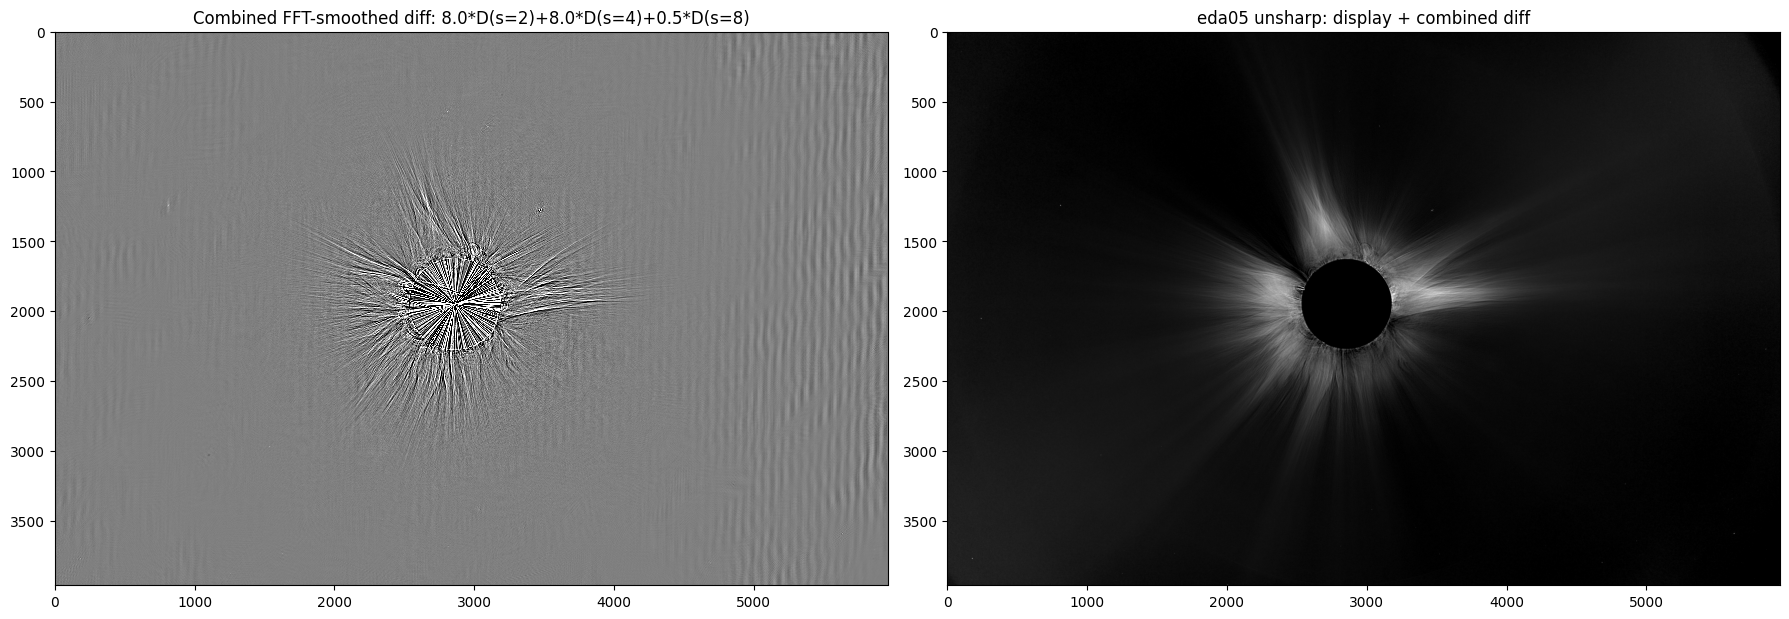

Saved /home/slavik/tmp/eda05_radial_normalize_sharpen_fft_smoothed_diff.png


In [22]:
# eda05: three FFT-smoothed residuals (display - Gauss blur, sigma = 2, 4, 8); combine 8*D2 + 8*D4 + 0.5*D8
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import tqdm
from pathlib import Path
from scipy.ndimage import gaussian_filter

# Requires: polar-fft-amp-utils cell (fftshift_complex_polar_preprocess).


def _blur_dist_to_corners(ci, cj, H, W):
    corners = [(0, 0), (H - 1, 0), (0, W - 1), (H - 1, W - 1)]
    return max(math.hypot(i - ci, j - cj) for i, j in corners)


def _blur_image_to_polar(img, center, radius_min, radius_max, n_r, n_theta, device, dtype):
    H, W = img.shape
    ci, cj = float(center[0]), float(center[1])
    y = torch.arange(n_r, device=device, dtype=dtype).view(-1, 1)
    x = torch.arange(n_theta, device=device, dtype=dtype).view(1, -1)
    r = radius_max - y * (radius_max - radius_min) / max(n_r - 1, 1)
    if n_theta > 1:
        theta = 2 * math.pi * x / (n_theta - 1)
    else:
        theta = torch.zeros_like(x, device=device, dtype=dtype)
    i_src = ci + r * torch.sin(theta)
    j_src = cj + r * torch.cos(theta)
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    polar = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    ).squeeze(0).squeeze(0)
    mask = (i_src >= 0) & (i_src < H) & (j_src >= 0) & (j_src < W)
    return polar, mask


def _blur_polar_to_cartesian(polar, center, radius_min, radius_max, H, W, device, dtype):
    n_r, n_theta = polar.shape
    ci, cj = float(center[0]), float(center[1])
    i = torch.arange(H, device=device, dtype=dtype).view(-1, 1)
    j = torch.arange(W, device=device, dtype=dtype).view(1, -1)
    r = torch.sqrt((i - ci) ** 2 + (j - cj) ** 2)
    theta = torch.atan2(i - ci, j - cj)
    theta = torch.where(theta < 0, theta + 2 * math.pi, theta)
    y_polar = (radius_max - r) * (n_r - 1) / max(radius_max - radius_min, 1e-9)
    x_polar = theta / (2 * math.pi) * (n_theta - 1) if n_theta > 1 else torch.zeros_like(theta)
    x_norm = 2.0 * x_polar / (n_theta - 1) - 1.0 if n_theta > 1 else torch.zeros_like(x_polar)
    y_norm = 2.0 * y_polar / (n_r - 1) - 1.0 if n_r > 1 else torch.zeros_like(y_polar)
    grid = torch.stack([x_norm, y_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        polar.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    ).squeeze(0).squeeze(0)
    valid = (r >= radius_min) & (r <= radius_max)
    return torch.where(valid, out, torch.zeros_like(out))


def prepare_display_for_blur_moon_polar(
    display_np,
    mi_crop,
    mj_crop,
    moon_r,
    band_half_width=3,
    mask_threshold=0.01,
):
    """Moon disk: per polar column, amax in rim band; set polar[i,j]=amax[j] for i>=i_star[j]; warp back; merge where mask>threshold."""
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dtype = torch.float32
    H, W = display_np.shape
    center = (float(mi_crop), float(mj_crop))
    radius_min = 0.0
    radius_max = _blur_dist_to_corners(mi_crop, mj_crop, H, W)
    n_r = max(int(math.ceil(2 * (radius_max - radius_min))) + 1, 2)
    n_theta = max(int(math.ceil(4 * math.pi * radius_max)) + 1, 2)
    img = torch.from_numpy(display_np.astype(np.float32, copy=False)).to(device=dev, dtype=dtype)
    polar, valid = _blur_image_to_polar(img, center, radius_min, radius_max, n_r, n_theta, dev, dtype)
    dr = (radius_max - radius_min) / max(n_r - 1, 1)
    i_cont = (radius_max - float(moon_r)) / max(dr, 1e-20)
    i_border = int(math.floor(i_cont))
    i_border = max(0, min(n_r - 1, i_border))
    i_lo = max(0, i_border - 3*band_half_width)
    i_hi = min(n_r, i_border)
    if i_lo >= i_hi:
        raise RuntimeError(f"moon polar band empty: i_border={i_border}, n_r={n_r}, band_half_width={band_half_width}")
    if not bool(valid[i_lo:i_hi, :].all().item()):
        raise AssertionError("invalid polar samples in moon rim band (expected all valid)")
    if i_border + 1 < n_r and not bool(valid[i_border + 1 :, :].all().item()):
        raise AssertionError("invalid polar samples for rows i > i_border (expected all valid)")
    band = polar[i_lo:i_hi, :]
    amax_vals, argmax_local = band.max(dim=0)
    amax_vals, _ = band.median(dim=0)
    i_star = i_lo + argmax_local.long()
    n_th = polar.shape[1]
    row_idx = torch.arange(n_r, device=dev, dtype=torch.long).view(-1, 1).expand(n_r, n_th)
    modify = row_idx >= i_star.unsqueeze(0)
    amax_2d = amax_vals.unsqueeze(0).expand(n_r, n_th)
    polar_filled = torch.where(modify, amax_2d, polar)
    modify_f = modify.to(dtype=dtype)
    cart_filled = _blur_polar_to_cartesian(polar_filled, center, radius_min, radius_max, H, W, dev, dtype)
    cart_mask = _blur_polar_to_cartesian(modify_f, center, radius_min, radius_max, H, W, dev, dtype)
    filled_np = cart_filled.detach().cpu().numpy()
    mask_np = cart_mask.detach().cpu().numpy()
    out = display_np.astype(np.float32, copy=True)
    sel = mask_np > mask_threshold
    out[sel] = filled_np[sel]
    if False:
        from pathlib import Path
        import numpy as _np

        _dbg_dir = Path("/home/slavik/tmp")
        _dbg_dir.mkdir(parents=True, exist_ok=True)
        _dp = "eda05_tmp_"

        def _save_dbg_png(stem, x):
            if hasattr(x, "detach"):
                a = x.detach().cpu().numpy()
            else:
                a = _np.asarray(x, dtype=_np.float64)
            a = _np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
            flat = a.ravel()
            if flat.size == 0:
                u8 = _np.zeros_like(a, dtype=_np.uint8)
            else:
                lo, hi = _np.percentile(flat, 1.0), _np.percentile(flat, 99.0)
                if hi <= lo + 1e-12:
                    mn, mx = float(_np.min(a)), float(_np.max(a))
                    if mx <= mn + 1e-12:
                        u8 = _np.zeros_like(a, dtype=_np.uint8)
                    else:
                        u8 = _np.clip((a - mn) / (mx - mn) * 255.0, 0.0, 255.0).astype(_np.uint8)
                else:
                    u8 = _np.clip((a - lo) / (hi - lo) * 255.0, 0.0, 255.0).astype(_np.uint8)
            Image.fromarray(u8).save(_dbg_dir / f"{_dp}{stem}.png")

        _save_dbg_png("display_np", display_np)
        _save_dbg_png("polar", polar)
        _save_dbg_png("polar_filled", polar_filled)
        _save_dbg_png("modify_f", modify_f)
        _save_dbg_png("cart_filled", cart_filled)
        _save_dbg_png("cart_mask", cart_mask)
        raise

    return out


def patch_window_flat_circle(a, dtype=np.float64):
    ci = (a - 1) / 2.0
    cj = (a - 1) / 2.0
    ii = np.arange(a, dtype=dtype).reshape(-1, 1)
    jj = np.arange(a, dtype=dtype).reshape(1, -1)
    r = np.hypot(ii - ci, jj - cj)
    R_flat = 0.667 * a / 2.0
    R_max = float(np.hypot(ci, cj))
    denom = max(R_max - R_flat, 1e-12)
    t = np.clip((r - R_flat) / denom, 0.0, 1.0)
    w = np.where(r <= R_flat, 1.0, 0.5 * (1.0 + np.cos(np.pi * t)))
    w = np.where(r >= R_max, 0.0, w)
    return w.astype(np.float32, copy=False)


def make_fft_mask2_percentile_for_tile(
    Fs, ci, cj, moon_i, moon_j, moon_r, epsilon=1e-12, p_near=90.0, p_far=99.8, exp_k=2.0
):
    """Amplitude gate q from shifted FFT Fs (same as eda04)."""
    R = max(float(moon_r), 1e-12)
    d = math.hypot(float(ci) - float(moon_i), float(cj) - float(moon_j))
    rho = d / R
    if rho <= 1.0:
        percentile = p_near
    elif rho >= 7.0:
        percentile = p_far
    else:
        t = (7.0 - rho) / 6.0
        v0 = 100.0 - p_far
        v1 = 100.0 - p_near
        v = v0 * (v1 / v0) ** t
        percentile = 100.0 - v
    aa = Fs.shape[0]
    assert Fs.shape == (aa, aa), Fs.shape
    dtype = Fs.real.dtype
    amplitude = torch.abs(Fs)
    th = torch.quantile(amplitude.reshape(-1), percentile / 100.0)
    newampl = (amplitude - th).clamp(min=0)
    q = newampl / (amplitude + epsilon)
    return q.to(dtype=dtype)


def sliding_diff_smooth_for_sigma(display, display_for_blur, blur_sigma, inward_median_span, mi_crop, mj_crop, moon_r, dev, a, stride):
    blurred = gaussian_filter(display_for_blur, sigma=blur_sigma, mode="nearest")
    diff_np = (display.astype(np.float64) - blurred.astype(np.float64)).astype(np.float32)
    H_d, W_d = display.shape
    assert H_d >= a and W_d >= a, (H_d, W_d, a)
    diff_t = torch.from_numpy(diff_np).to(device=dev, dtype=torch.float32)
    win_np = patch_window_flat_circle(a)
    win = torch.from_numpy(win_np).to(dev)
    acc = torch.zeros(H_d, W_d, device=dev, dtype=torch.float32)
    wsum = torch.zeros(H_d, W_d, device=dev, dtype=torch.float32)
    row_starts = list(range(0, H_d - a + 1, stride))
    col_starts = list(range(0, W_d - a + 1, stride))
    for r0 in tqdm.tqdm(row_starts, desc=f"FFT-smooth diff sigma={blur_sigma}"):
        for c0 in col_starts:
            patch = diff_t[r0 : r0 + a, c0 : c0 + a]
            p_w = patch * win
            F_fft = torch.fft.fft2(p_w)
            Fs = torch.fft.fftshift(F_fft)
            Fs_proc = fftshift_complex_polar_preprocess(Fs, inward_median_span)
            tc_i = r0 + 0.5 * (a - 1)
            tc_j = c0 + 0.5 * (a - 1)
            G = make_fft_mask2_percentile_for_tile(Fs_proc, tc_i, tc_j, mi_crop, mj_crop, moon_r)
            Fm = torch.fft.ifftshift(Fs_proc * G)
            recon = torch.fft.ifft2(Fm).real
            acc[r0 : r0 + a, c0 : c0 + a] += recon * win
            wsum[r0 : r0 + a, c0 : c0 + a] += win
    return (acc / wsum.clamp(min=1e-9)).cpu().numpy()


a = 256
stride = 8
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

display_for_blur = prepare_display_for_blur_moon_polar(display, mi_crop, mj_crop, moon_r)

diff_smooth_r2 = sliding_diff_smooth_for_sigma(
    display_for_blur, display_for_blur, 2.0, inward_median_span, mi_crop, mj_crop, moon_r, dev, a, stride
)
diff_smooth_r4 = sliding_diff_smooth_for_sigma(
    display_for_blur, display_for_blur, 4.0, inward_median_span, mi_crop, mj_crop, moon_r, dev, a, stride
)
diff_smooth_r8 = sliding_diff_smooth_for_sigma(
    display_for_blur, display_for_blur, 8.0, inward_median_span, mi_crop, mj_crop, moon_r, dev, a, stride
)

combined_diff = strength_r2 * diff_smooth_r2 + strength_r4 * diff_smooth_r4 + strength_r8 * diff_smooth_r8
sharpened_fft_diff = display + combined_diff
sharpened_fft_diff = np.clip(sharpened_fft_diff, 0.0, 1.0)
sharpened_fft_diff[moon_mask] = 0.0

out_png = Path(PKL_DIR) / "eda05_radial_normalize_sharpen_fft_smoothed_diff.png"
Image.fromarray((sharpened_fft_diff * 255).clip(0, 255).astype(np.uint8)).save(out_png)
vlim_ds = float(np.percentile(np.abs(combined_diff), 99.0))
vlim_ds = max(vlim_ds, 1e-9)
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].imshow(combined_diff, cmap="gray", vmin=-vlim_ds, vmax=vlim_ds, interpolation="nearest")
axes[0].set_title(
    f"Combined FFT-smoothed diff: {strength_r2}*D(s=2)+{strength_r4}*D(s=4)+{strength_r8}*D(s=8)"
)
axes[1].imshow(sharpened_fft_diff, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("eda05 unsharp: display + combined diff")
plt.tight_layout()
plt.show()
print(f"Saved {out_png}")

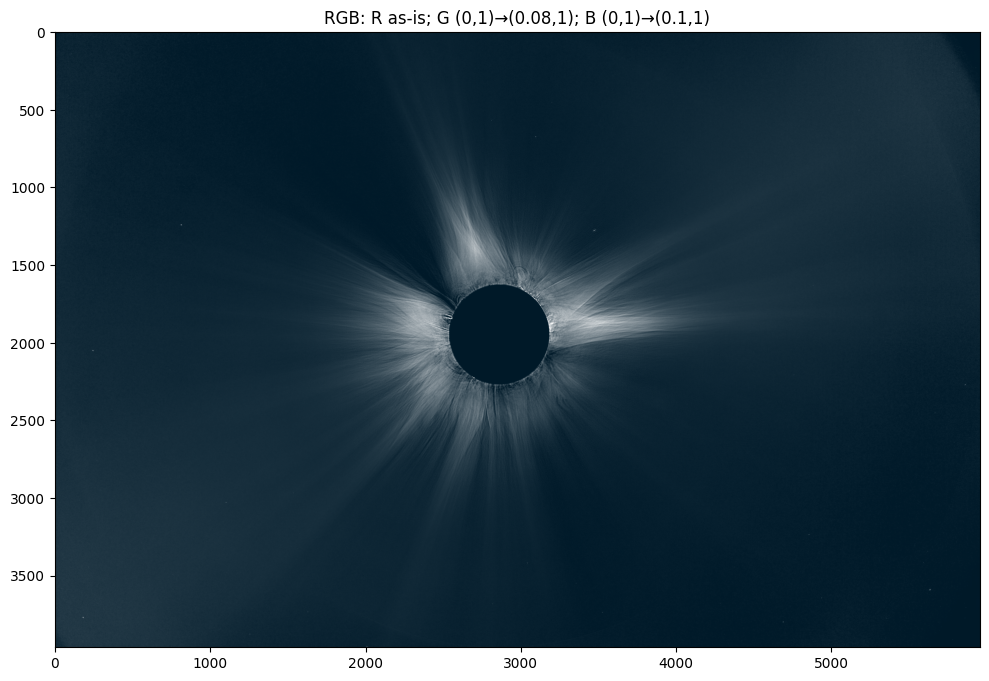

Saved /home/slavik/tmp/eda05_rgb_rescaled.png


In [23]:
# Grayscale -> RGB: R unchanged; G and B rescale black point (lift shadows)
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

gray = np.clip(sharpened_fft_diff.astype(np.float64), 0.0, 1.0)
R = gray
G = 0.10 + 0.90 * gray  # (0, 1) -> (0.10, 1)
B = 0.16 + 0.84 * gray  # (0, 1) -> (0.16, 1)
display_rgb = np.clip(np.stack([R, G, B], axis=-1), 0.0, 1.0)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(display_rgb)
ax.set_title("RGB: R as-is; G (0,1)→(0.08,1); B (0,1)→(0.1,1)")
plt.tight_layout()
plt.show()

out_png = Path(PKL_DIR) / "eda05_rgb_rescaled.png"
Image.fromarray((display_rgb * 255).round().clip(0, 255).astype(np.uint8)).save(out_png)
print(f"Saved {out_png}")

In [ ]:
# Save radial params (mean_at per row_fraction, p3_at) for downstream use
import pickle
from pathlib import Path

out_path = Path(PKL_DIR) / "eda05_radial.pkl"
with open(out_path, "wb") as fd:
    pickle.dump({
        "row_fractions": row_fractions,
        "mean_at_list": mean_at_list,
        "p3_at": p3_at.cpu().numpy(),
        "moon_mask": moon_mask,
    }, fd)
print(f"Saved {out_path}")